<a href="https://colab.research.google.com/github/Thasli-ma-2004/Data-Analytics-using-Python-Project/blob/main/Student_Performance_Analytics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GENERATE THE DATASET**

In [ ]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)
n_students = 50

# Generate expanded student data
data = {
    'Roll_No': range(1001, 1001 + n_students),
    'Name': [f'Student_{i}' for i in range(1, n_students + 1)],
    'Class': np.random.choice(['CSE-A', 'CSE-B'], size=n_students),
    'Attendance_Pct': np.random.randint(60, 100, size=n_students),
    'Assignment_Score': np.random.randint(10, 20, size=n_students),
    'Maths': np.random.randint(30, 100, size=n_students),
    'Physics': np.random.randint(35, 100, size=n_students),
    'Chemistry': np.random.randint(32, 100, size=n_students),
    'English': np.random.randint(40, 100, size=n_students),
    'Computer': np.random.randint(45, 100, size=n_students)
}

df = pd.DataFrame(data)
df.to_csv('student_performance.csv', index=False)

print("Dataset 'student_performance.csv' created successfully!")
print(f"Total Students: {len(df)}")
print(f"Total Columns: {len(df.columns)}")

display(df.head())

Dataset 'student_performance.csv' created successfully!
Total Students: 50
Total Columns: 10


,Roll_No,Name,Class,Attendance_Pct,Assignment_Score,Maths,Physics,Chemistry,English,Computer
0,1001,Student_1,CSE-A,62,18,42,66,66,57,95
1,1002,Student_2,CSE-B,96,17,61,89,92,64,67
2,1003,Student_3,CSE-A,66,10,88,90,72,81,59
3,1004,Student_4,CSE-A,80,17,57,51,64,70,72
4,1005,Student_5,CSE-A,68,17,95,72,99,93,78


# **DATA CLEANING & ADVANCED ANALYTICS**

In [ ]:
# Load Dataset
import pandas as pd
import numpy as np

df = pd.read_csv('student_performance.csv')
subjects = ['Maths', 'Physics', 'Chemistry', 'English', 'Computer']

# Calculate Total and Average (Marks out of 100)
df['Total_Marks'] = df[subjects].sum(axis=1)
df['Average'] = round(df[subjects].mean(axis=1), 2)

# Pass/Fail Status (Minimum 40 in all subjects)
df['Status'] = np.where((df[subjects] >= 40).all(axis=1), 'Pass', 'Fail')

# Grade Calculation
def get_grade(row):
    if row['Status'] == 'Fail': return 'RA'
    elif row['Average'] >= 90: return 'O'
    elif row['Average'] >= 80: return 'A+'
    elif row['Average'] >= 70: return 'A'
    elif row['Average'] >= 60: return 'B'
    elif row['Average'] >= 50: return 'C'
    else: return 'P'
df['Grade'] = df.apply(get_grade, axis=1)

# Student Ranking (Based on Total Marks)
df['Rank'] = df['Total_Marks'].rank(ascending=False, method='min').astype(int)

# Best and Weakest Subject
df['Best_Subject'] = df[subjects].idxmax(axis=1)
df['Weakest_Subject'] = df[subjects].idxmin(axis=1)

# Risk Level Classification
df['Risk_Level'] = np.where((df['Attendance_Pct'] < 75) | (df['Status'] == 'Fail'), 'High Risk', 'Low Risk')

# Performance Category Logic
def performance_category(avg):
    if avg >= 85: return "Excellent"
    elif avg >= 70: return "Good"
    elif avg >= 55: return "Average"
    else: return "Needs Improvement"

df['Performance_Category'] = df['Average'].apply(performance_category)

# Save Cleaned Data
df.to_csv('cleaned_student_performance.csv', index=False)

print("Data Cleaning and Advanced Analysis Complete!")

display(df[['Roll_No', 'Name', 'Total_Marks', 'Average', 'Grade', 'Performance_Category', 'Rank', 'Risk_Level']].head(10))

# Display Top 10 Students
top_students = df.sort_values('Rank').head(10)
print("\nTop 10 Students:")
display(top_students[['Rank', 'Name', 'Total_Marks', 'Grade', 'Performance_Category']])

# Weak Students Analysis
weak_students = df[df['Status'] == 'Fail']

print("\n--- Weak Students Analysis ---")
if not weak_students.empty:
    print(f"Total students needing improvement: {len(weak_students)}")
    display(weak_students[['Roll_No', 'Name', 'Average', 'Grade', 'Risk_Level']])
else:
    print("No weak students found!")


# Final Insights Output
print("\n" + "="*40)
print(" 📊 FINAL INSIGHTS OUTPUT ")
print("="*40)
print(f"Total Students Evaluated: {len(df)}")
pass_pct = round((df['Status'] == 'Pass').mean() * 100, 2)
print(f"Overall Pass Percentage: {pass_pct}%")

print("\n🏆 Top Performer:")
top_performer = df.loc[df['Rank'] == 1, ['Name', 'Total_Marks', 'Grade', 'Class']].iloc[0]
print(f"Name: {top_performer['Name']} | Class: {top_performer['Class']} | Marks: {top_performer['Total_Marks']} | Grade: {top_performer['Grade']}")
print("="*40)


Data Cleaning and Advanced Analysis Complete!


,Roll_No,Name,Total_Marks,Average,Grade,Performance_Category,Rank,Risk_Level
0,1001,Student_1,326,65.2,B,Average,30,High Risk
1,1002,Student_2,373,74.6,A,Good,14,Low Risk
2,1003,Student_3,390,78.0,A,Good,8,High Risk
3,1004,Student_4,314,62.8,B,Average,38,Low Risk
4,1005,Student_5,437,87.4,A+,Excellent,1,High Risk
5,1006,Student_6,336,67.2,B,Average,28,Low Risk
6,1007,Student_7,282,56.4,C,Average,47,Low Risk
7,1008,Student_8,339,67.8,B,Average,27,High Risk
8,1009,Student_9,409,81.8,A+,Good,3,Low Risk
9,1010,Student_10,281,56.2,RA,Average,48,High Risk



Top 10 Students:


,Rank,Name,Total_Marks,Grade,Performance_Category
4,1,Student_5,437,A+,Excellent
38,2,Student_39,421,A+,Good
8,3,Student_9,409,A+,Good
49,4,Student_50,406,A+,Good
42,5,Student_43,396,A,Good
46,5,Student_47,396,A,Good
12,7,Student_13,393,A,Good
2,8,Student_3,390,A,Good
30,9,Student_31,379,RA,Good
29,10,Student_30,378,A,Good



--- Weak Students Analysis ---
Total students needing improvement: 17


,Roll_No,Name,Average,Grade,Risk_Level
9,1010,Student_10,56.2,RA,High Risk
10,1011,Student_11,61.6,RA,High Risk
11,1012,Student_12,65.0,RA,High Risk
16,1017,Student_17,64.4,RA,High Risk
19,1020,Student_20,65.2,RA,High Risk
20,1021,Student_21,70.6,RA,High Risk
22,1023,Student_23,58.4,RA,High Risk
30,1031,Student_31,75.8,RA,High Risk
31,1032,Student_32,63.4,RA,High Risk
32,1033,Student_33,74.8,RA,High Risk



 📊 FINAL INSIGHTS OUTPUT 
Total Students Evaluated: 50
Overall Pass Percentage: 66.0%

🏆 Top Performer:
Name: Student_5 | Class: CSE-A | Marks: 437 | Grade: A+


# **GENERATE VISUALIZATIONS**

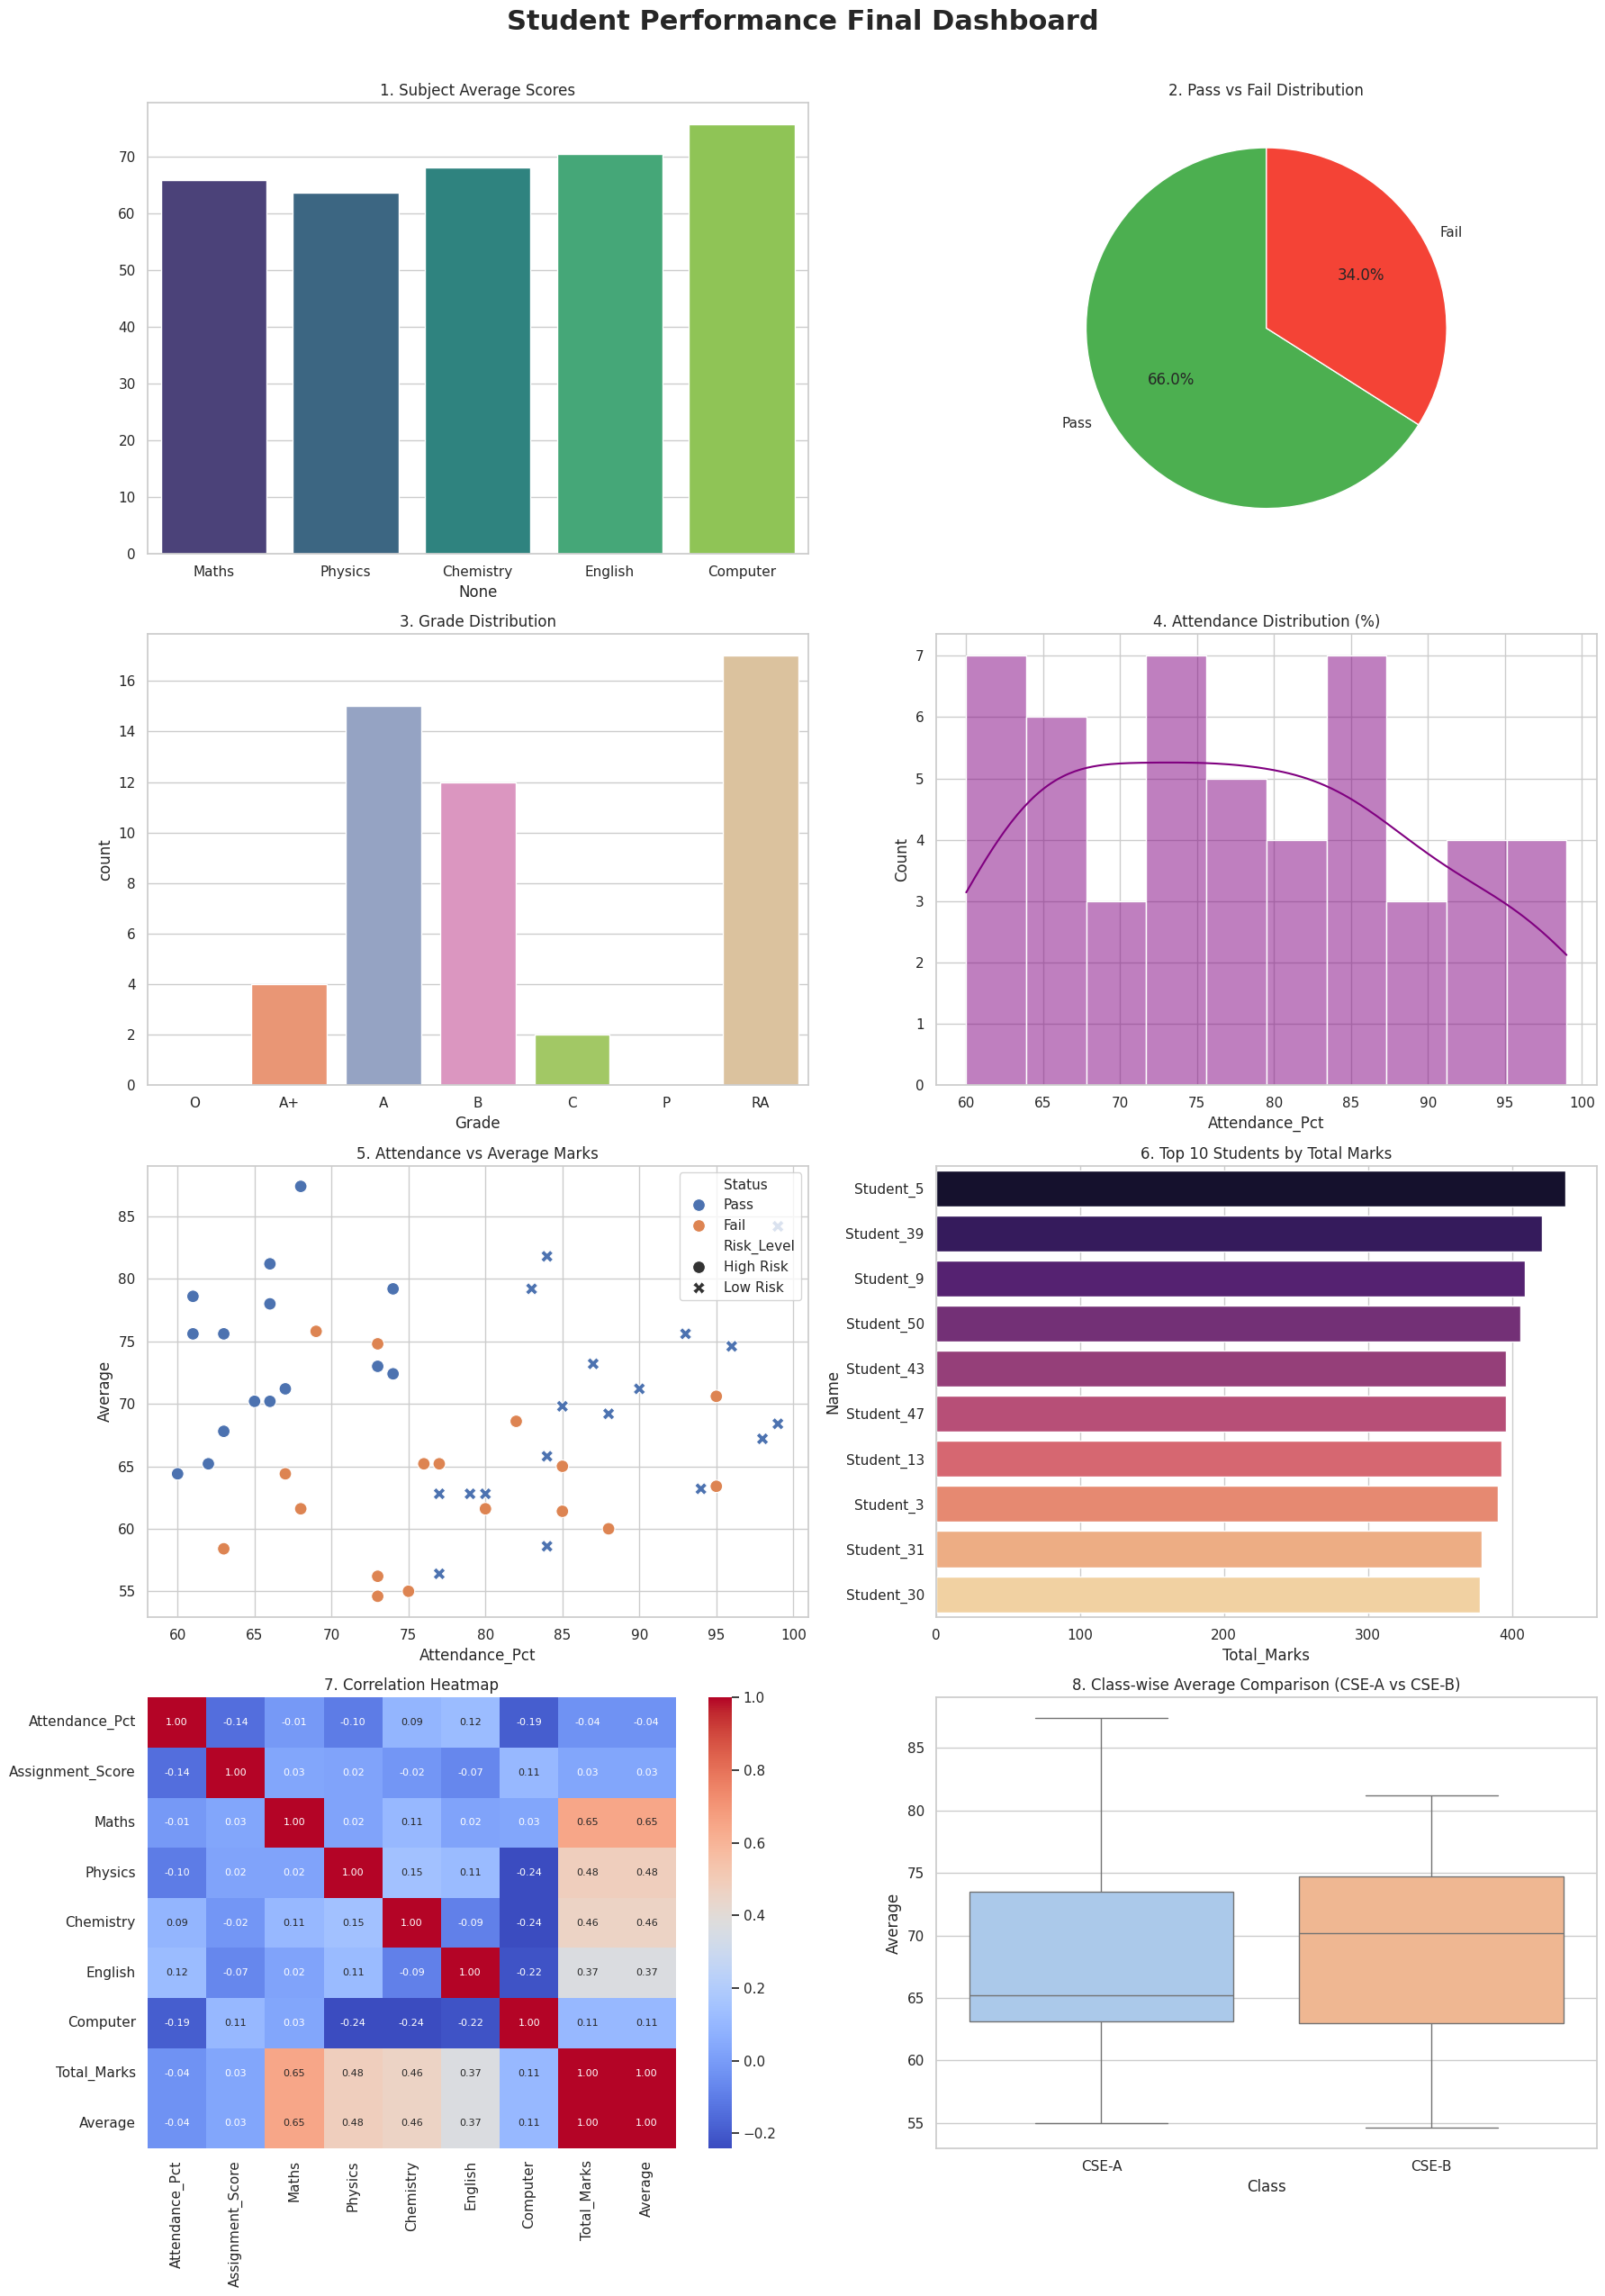

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('cleaned_student_performance.csv')
subjects = ['Maths', 'Physics', 'Chemistry', 'English', 'Computer']

# Create a large figure to hold all 8 charts
fig, axes = plt.subplots(4, 2, figsize=(18, 26))
fig.suptitle('Student Performance Final Dashboard', fontsize=22, fontweight='bold', y=0.98)

# 1. Subject Average Bar Chart
subj_avg = df[subjects].mean()
sns.barplot(x=subj_avg.index, y=subj_avg.values, ax=axes[0,0], palette="viridis")
axes[0,0].set_title("1. Subject Average Scores")

# 2. Pass vs Fail Pie Chart
status_counts = df['Status'].value_counts()
axes[0,1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[0,1].set_title("2. Pass vs Fail Distribution")

# 3. Grade Distribution
sns.countplot(data=df, x='Grade', order=['O', 'A+', 'A', 'B', 'C', 'P', 'RA'], ax=axes[1,0], palette="Set2")
axes[1,0].set_title("3. Grade Distribution")

# 4. Attendance Distribution
sns.histplot(df['Attendance_Pct'], bins=10, kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title("4. Attendance Distribution (%)")

# 5. Attendance vs Average Scatter Plot
sns.scatterplot(data=df, x='Attendance_Pct', y='Average', hue='Status', style='Risk_Level', s=100, ax=axes[2,0])
axes[2,0].set_title("5. Attendance vs Average Marks")

# 6. Top 10 Students Chart
top_10 = df.sort_values('Rank').head(10)
sns.barplot(data=top_10, y='Name', x='Total_Marks', ax=axes[2,1], palette="magma")
axes[2,1].set_title("6. Top 10 Students by Total Marks")

# 7. Correlation Heatmap
corr_matrix = df[['Attendance_Pct', 'Assignment_Score', 'Maths', 'Physics', 'Chemistry', 'English', 'Computer', 'Total_Marks', 'Average']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[3,0], annot_kws={"size": 8})
axes[3,0].set_title("7. Correlation Heatmap")

# 8. Class Comparison Chart (Average by Class)
sns.boxplot(data=df, x='Class', y='Average', ax=axes[3,1], palette="pastel")
axes[3,1].set_title("8. Class-wise Average Comparison (CSE-A vs CSE-B)")

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()